### Import the libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Better plot style
plt.style.use("ggplot")

### Load the DataSet

In [2]:
df = pd.read_csv("../data/raw/cars.csv")

### View the DataSet

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Dataset Shape

In [4]:
df.shape

(301, 9)

### Columns Names

In [5]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

### DataSet Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


## Phase 1: Dataset Inspection

### Check for Missing Values

In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

### Check for Duplicate Rows

In [8]:
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
296    False
297    False
298    False
299    False
300    False
Length: 301, dtype: bool>

### Statistical Summary

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0


### Categorical Summary

In [12]:
df.describe(include=["object", "string"]).T

,count,unique,top,freq
Car_Name,301,98,city,26
Fuel_Type,301,3,Petrol,239
Selling_type,301,2,Dealer,195
Transmission,301,2,Manual,261


### Display Random Samples

In [11]:
df.sample(5, random_state=42)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
177,Honda Activa 125,2016,0.35,0.57,24000,Petrol,Individual,Automatic,0
289,city,2016,10.11,13.60,10980,Petrol,Dealer,Manual,0
228,verna,2012,4.95,9.40,60000,Diesel,Dealer,Manual,0
198,Bajaj Discover 125,2011,0.15,0.57,35000,Petrol,Individual,Manual,1
60,corolla altis,2013,6.95,18.61,40001,Petrol,Dealer,Manual,0


# Exploratory Data Analysis

## Phase 2: Univariate Analysis

### 1. Distribution of Selling Price

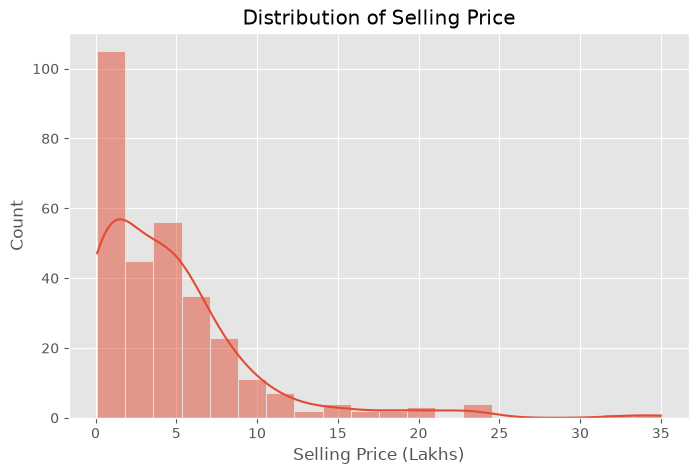

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=20, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Count")

plt.show()

#### Observations:

- Most cars have a selling price below 10 lakhs.
- The distribution is positively (right) skewed, meaning there are a few expensive cars but many lower-priced ones.
- High-priced cars are relatively rare and may act as outliers.

### 2. Selling Price Boxplot

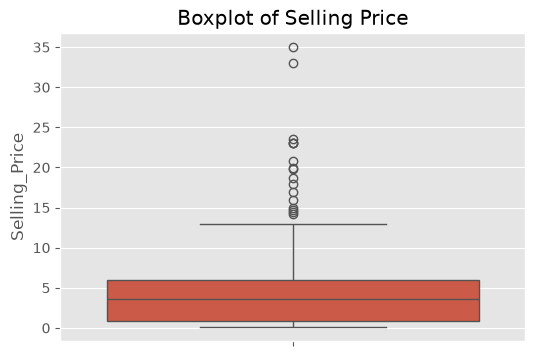

In [14]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Selling_Price"])

plt.title("Boxplot of Selling Price")

plt.show()

#### Observations:

- A few cars have significantly higher selling prices than the rest.
- These values appear as outliers in the boxplot.
- Most selling prices are concentrated within a relatively small range.

### 3. Distribution of Present Price

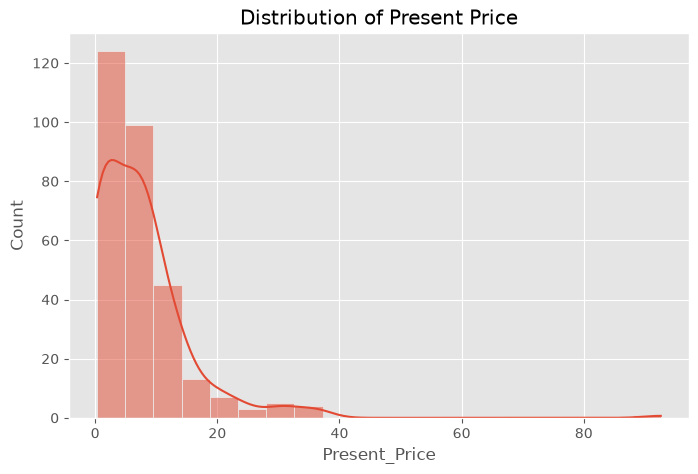

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Present_Price"], bins=20, kde=True)

plt.title("Distribution of Present Price")

plt.show()

#### Observations:

- Most cars have a present showroom price below 15 lakhs.
- The distribution is right-skewed.
- A few premium cars have much higher showroom prices.

### 4. Present Price Boxplot

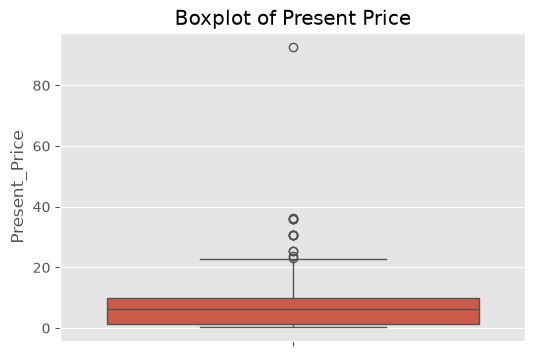

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Present_Price"])

plt.title("Boxplot of Present Price")

plt.show()

#### Observations:

- The dataset contains several high-value showroom prices that appear as outliers.
- Most cars fall within the lower price range.
- These outliers should be considered during model evaluation but are not necessarily incorrect.

### 5. Distribution of Driven Kilometres

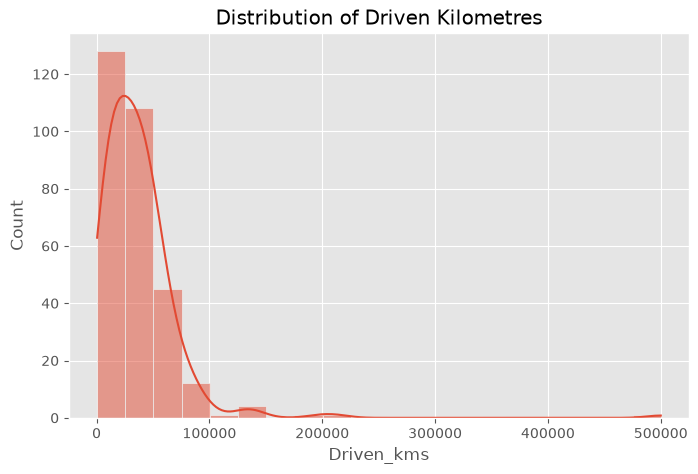

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Driven_kms"], bins=20, kde=True)

plt.title("Distribution of Driven Kilometres")

plt.show()

#### Observations:

- Most cars have been driven fewer than 60,000 km.
- The distribution is highly right-skewed.
- A small number of cars have extremely high mileage.

### 6. Driven Kilometres Boxplot

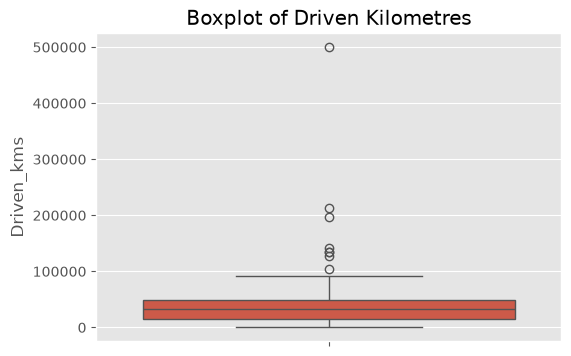

In [18]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Driven_kms"])

plt.title("Boxplot of Driven Kilometres")

plt.show()

#### Observations:

- Several cars have unusually high mileage compared with the rest of the dataset.
- These observations appear as outliers.
- High mileage can have a significant impact on selling price.

## Phase 3: Categorical Analysis

### Fuel Type Countplot

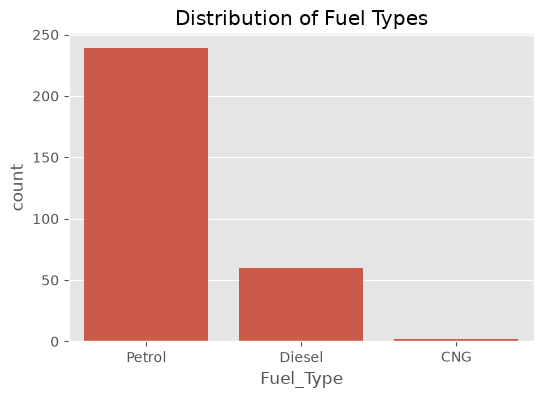

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="Fuel_Type", data=df)

plt.title("Distribution of Fuel Types")

plt.show()

#### Observations:

- Petrol cars are the most common in the dataset.
- Diesel cars are the second most common.
- CNG cars represent only a small portion of the data.

### Transmission Countplot

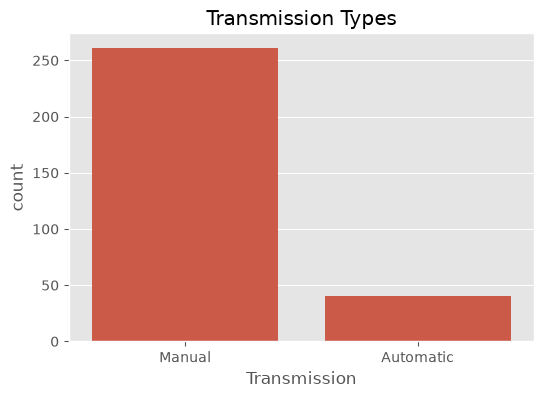

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="Transmission", data=df)

plt.title("Transmission Types")

plt.show()

#### Observations:

- Manual transmission vehicles dominate the dataset.
- Automatic transmission vehicles are comparatively fewer.
- This class imbalance should be considered during model interpretation.

### Selling Type Countplot

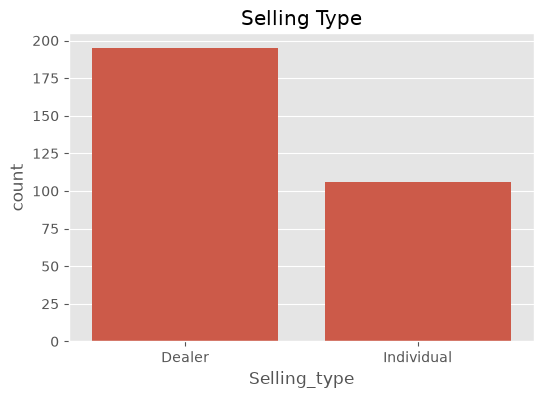

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x="Selling_type", data=df)

plt.title("Selling Type")

plt.show()

#### Observations:

- Most cars are sold by individual owners.
- Dealer-listed vehicles form a smaller portion of the dataset.
- Trustmark Dealer vehicles are the least common category.

## Phase 4: Bivariate Analysis

### Selling Price vs Year

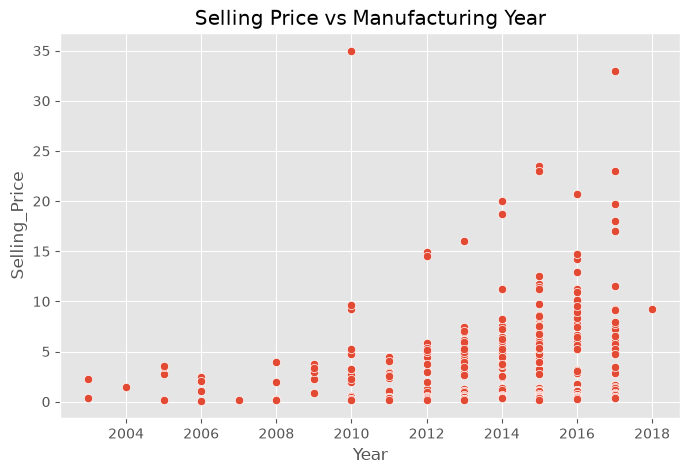

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Year",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price vs Manufacturing Year")

plt.show()

#### Observations:

- Newer cars generally have higher selling prices.
- Older cars tend to sell for lower prices due to depreciation.
- There is a positive relationship between manufacturing year and selling price.

### Selling Price vs Driven Kilometres

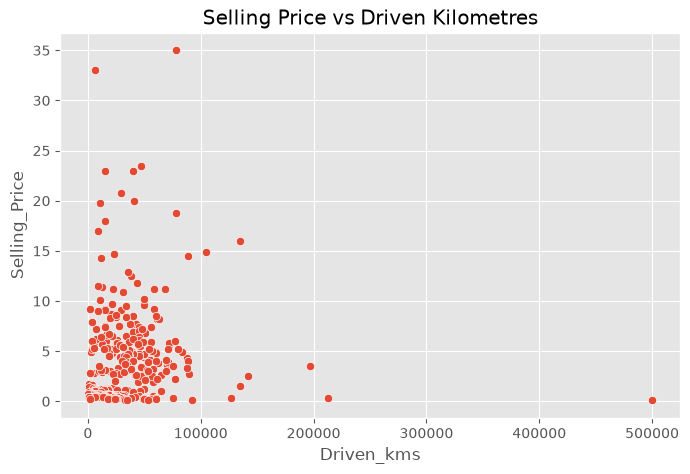

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Driven_kms",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price vs Driven Kilometres")

plt.show()

#### Observations:

- Cars with higher mileage generally have lower selling prices.
- Lower-mileage cars tend to retain more value.
- The relationship is negative but not perfectly linear.

### Fuel Type vs Selling Price

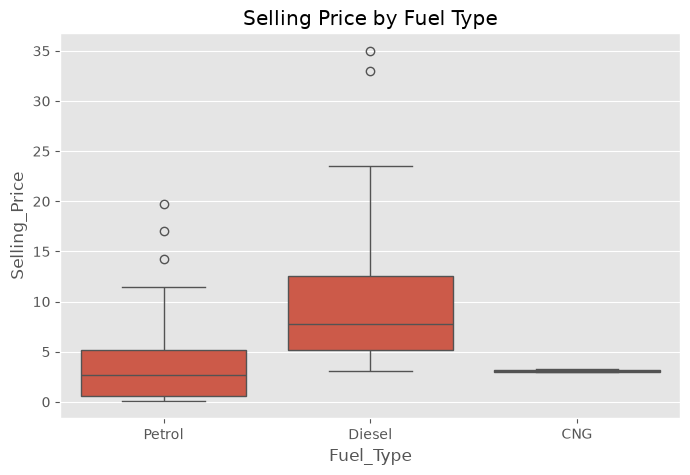

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price by Fuel Type")

plt.show()

#### Observations:

- Diesel cars generally have higher selling prices than petrol cars.
- CNG vehicles are fewer in number and occupy a lower price range.
- Fuel type appears to influence resale value.

### Selling Price by Transmission

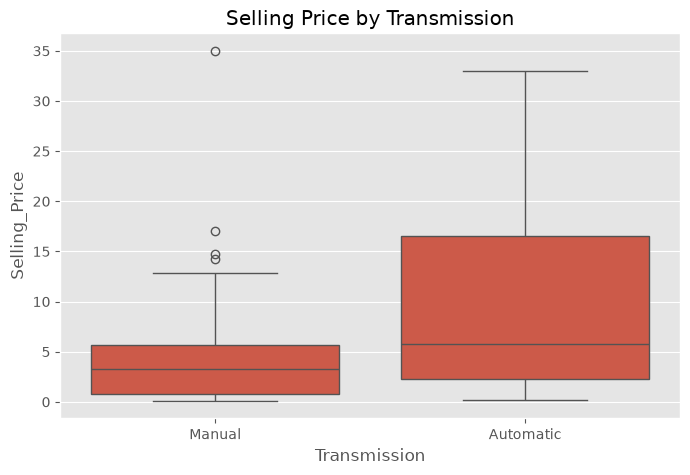

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Transmission",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price by Transmission")

plt.show()

#### Observations:

- Automatic cars generally have higher selling prices than manual cars.
- Manual cars show a wider spread because they are more common.
- Transmission type influences resale price.

## Phase 5: Correlation

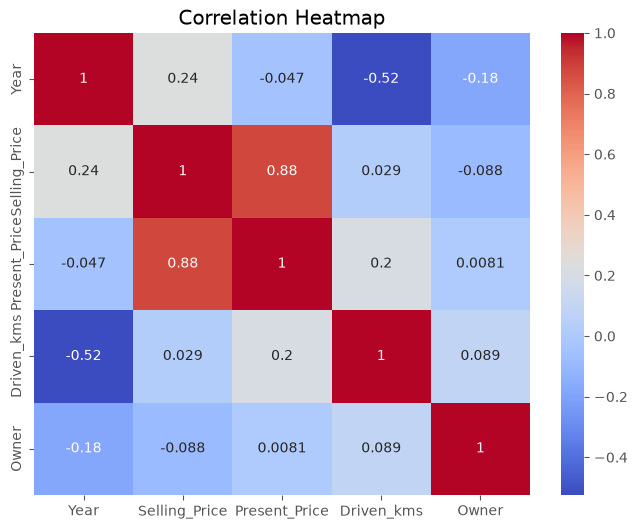

In [26]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

#### Observations:

- Present_Price has the strongest positive correlation with Selling_Price.
- Year shows a positive relationship with selling price, indicating newer cars are typically worth more.
- Driven_kms is negatively correlated with selling price, suggesting that higher mileage tends to reduce resale value.